In [14]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from caveclient import CAVEclient

In [15]:
DATASET = "v1dd_public"
MATERIALIZATION_VERSION = 1196
LAYER_ORDER = ["L2", "L3", "L4", "L5", "L6"]
# Nucleus coordinates in v1dd tables are voxel coordinates (x, y, z).
VOXEL_SIZE_NM = np.array([8, 8, 40])
OUT = Path("proofread_ffi_results")
OUT.mkdir(exist_ok=True)

In [16]:
def true_mask(series):
    """Handle proofread flags stored as bools or strings."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.lower().eq("true")


def connection_table(synapses, name):
    """One row per directed neuron pair; size is its synapse count."""
    return (
        synapses.groupby(["pre_pt_root_id", "post_pt_root_id"])
        .size()
        .rename(name)
        .reset_index()
    )


def save(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / name, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [17]:
# ---------- Load data and annotations ----------
client = CAVEclient(
    DATASET,
    server_address="https://global.em.brain.allentech.org",
    auth_token=os.environ["API_SECRET"],
)

thal_syn = pd.read_csv("thal_syn.csv")
I_syn = pd.read_csv("I_syn.csv")

cell_types = client.materialize.query_table(
    "cell_type_multifeature_v1",
    materialization_version=MATERIALIZATION_VERSION,
)
ct = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].drop_duplicates("pt_root_id")
ct["layer"] = ct["cell_type"].str.extract(r"(L[2-6])")

proof = client.materialize.query_table(
    "proofreading_status_and_strategy",
    materialization_version=MATERIALIZATION_VERSION,
)


In [18]:
# E neurons must have proofread dendrites; I neurons must have proofread axons.
proofread_E_ids = pd.Index(
    proof.loc[true_mask(proof["status_dendrite"]), "pt_root_id"].dropna().unique()
).intersection(ct.loc[ct["classification_system"].eq("excitatory"), "pt_root_id"])
proofread_I_ids = pd.Index(
    proof.loc[true_mask(proof["status_axon"]), "pt_root_id"].dropna().unique()
).intersection(ct.loc[ct["classification_system"].eq("inhibitory"), "pt_root_id"])

E_meta = ct.loc[ct["pt_root_id"].isin(proofread_E_ids)].copy()
I_meta = ct.loc[ct["pt_root_id"].isin(proofread_I_ids)].copy()
E_meta

,pt_root_id,classification_system,cell_type,layer
0,864691132654552792,excitatory,L3IT,L3
16,864691132843155974,excitatory,L2IT,L2
41,864691132782479006,excitatory,L6IT,L6
59,864691132730996275,excitatory,L2IT,L2
61,864691132722774857,excitatory,L5ET,L5
...,...,...,...,...
47997,864691132654904280,excitatory,L4IT,L4
48009,864691133046970980,excitatory,L2IT,L2
48057,864691132786014760,excitatory,L4IT,L4
48060,864691132653866455,excitatory,L3IT,L3


In [19]:
I_meta

,pt_root_id,classification_system,cell_type,layer
310,864691132923215329,inhibitory,DTC,<NA>
377,864691132616354625,inhibitory,ITC,<NA>
470,864691132657293527,inhibitory,DTC,<NA>
572,864691132664546211,inhibitory,STC,<NA>
724,864691132729533614,inhibitory,PTC,<NA>
...,...,...,...,...
47747,864691132683090805,inhibitory,ITC,<NA>
47825,864691132690984696,inhibitory,PTC,<NA>
47840,864691132849454803,inhibitory,PTC,<NA>
47863,864691132819642111,inhibitory,ITC,<NA>


In [20]:
# ---------- Assign each proofread I neuron the layer of its nearest E neuron ----------
nuclei = client.materialize.query_table(
    "nucleus_detection_v0",
    materialization_version=MATERIALIZATION_VERSION,
)
position_col = "pt_position" if "pt_position" in nuclei.columns else "ctr_pt_position"
nuclei = nuclei[["pt_root_id", position_col]].drop_duplicates("pt_root_id")

E_pos = E_meta[["pt_root_id", "layer"]].merge(nuclei, on="pt_root_id").dropna(subset=["layer"])
I_pos = I_meta[["pt_root_id"]].merge(nuclei, on="pt_root_id")
if E_pos.empty or I_pos.empty:
    raise ValueError("No proofread E or I soma positions were found.")

e_xyz = np.vstack(E_pos[position_col].map(np.asarray)) * VOXEL_SIZE_NM
i_xyz = np.vstack(I_pos[position_col].map(np.asarray)) * VOXEL_SIZE_NM


In [21]:
# Chunking avoids making one very large I-by-E distance matrix.
nearest_rows = []
for start in range(0, len(I_pos), 500):
    xyz = i_xyz[start : start + 500]
    distance2 = ((xyz[:, None, :] - e_xyz[None, :, :]) ** 2).sum(axis=2)
    nearest = distance2.argmin(axis=1)
    block = I_pos.iloc[start : start + len(xyz)].copy()
    block["nearest_E_id"] = E_pos.iloc[nearest]["pt_root_id"].to_numpy()
    block["layer"] = E_pos.iloc[nearest]["layer"].to_numpy()
    block["distance_to_nearest_E_nm"] = np.sqrt(distance2[np.arange(len(xyz)), nearest])
    nearest_rows.append(block)

I_layers = pd.concat(nearest_rows, ignore_index=True)
I_layers.to_csv(OUT / "inhibitory_nearest_excitatory_layer.csv", index=False)


In [22]:
# ---------- Keep only proofread E dendrites and proofread I axons ----------
typed_thal = thal_syn.merge(
    ct[["pt_root_id", "classification_system"]],
    left_on="post_pt_root_id", right_on="pt_root_id", how="inner",
)
TE_syn = typed_thal.loc[
    typed_thal["classification_system"].eq("excitatory")
    & typed_thal["post_pt_root_id"].isin(proofread_E_ids)
].copy()
TI_syn = typed_thal.loc[
    typed_thal["classification_system"].eq("inhibitory")
    & typed_thal["post_pt_root_id"].isin(proofread_I_ids)
].copy()
IE_syn = I_syn.loc[
    I_syn["pre_pt_root_id"].isin(proofread_I_ids)
    & I_syn["post_pt_root_id"].isin(proofread_E_ids)
].copy()

TE = connection_table(TE_syn, "direct_size")
TI = connection_table(TI_syn, "TI_size")
IE = connection_table(IE_syn, "IE_size")

# Synapse-table `size` sums per connection. These are separate from the
# connection tables above, whose "size" variables are synapse counts. The raw
# table units are retained; no conversion to area or volume is applied.
TE_physical = (
    TE_syn.groupby(["pre_pt_root_id", "post_pt_root_id"])["size"]
    .sum().rename("direct_physical_size").reset_index()
)
TI_physical = (
    TI_syn.groupby(["pre_pt_root_id", "post_pt_root_id"])["size"]
    .sum().rename("TI_physical_size").reset_index()
)
IE_physical = (
    IE_syn.groupby(["pre_pt_root_id", "post_pt_root_id"])["size"]
    .sum().rename("IE_physical_size").reset_index()
)

W_TE = TE.pivot(index="pre_pt_root_id", columns="post_pt_root_id", values="direct_size").fillna(0)
W_TI = TI.pivot(index="pre_pt_root_id", columns="post_pt_root_id", values="TI_size").fillna(0)
W_IE = IE.pivot(index="pre_pt_root_id", columns="post_pt_root_id", values="IE_size").fillna(0)
W_TE_physical = TE_physical.pivot(
    index="pre_pt_root_id", columns="post_pt_root_id", values="direct_physical_size"
).fillna(0)
W_IE_physical = IE_physical.pivot(
    index="pre_pt_root_id", columns="post_pt_root_id", values="IE_physical_size"
).fillna(0)

W_TI_physical = TI_physical.pivot(
    index="pre_pt_root_id", columns="post_pt_root_id", values="TI_physical_size"
).fillna(0)


In [24]:
# Same proofread inhibitory neuron must participate in T->I and I->E.
common_I = W_TI.columns.intersection(W_IE.index)
common_T = W_TE.index.union(W_TI.index)
common_E = W_TE.columns.union(W_IE.columns)
direct = W_TE.reindex(index=common_T, columns=common_E, fill_value=0)
TI_exists = W_TI.reindex(index=common_T, columns=common_I, fill_value=0).gt(0).astype(int)
TI_count = W_TI.reindex(index=common_T, columns=common_I, fill_value=0)
IE_size = W_IE.reindex(index=common_I, columns=common_E, fill_value=0)

TI_physical_size = W_TI_physical.reindex(
    index=common_T,
    columns=common_I,
    fill_value=0,
)

IE_physical_size = W_IE_physical.reindex(
    index=common_I,
    columns=common_E,
    fill_value=0,
)

weighted_physical_path_strength = (
    TI_physical_size @ IE_physical_size
)

In [25]:
IE_size

post_pt_root_id,864691132533275738,864691132533347418,864691132534275418,864691132534315610,864691132534826074,864691132535349082,864691132535664474,864691132535950170,864691132536503642,864691132536881242,...,864691133310347088,864691133310376272,864691133310556752,864691133311276624,864691133312229968,864691133312850768,864691133313558608,864691133313636944,864691133313665616,864691133314166096
864691132536286810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132536904794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
864691132544823185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132557909513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132558380553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691133121058917,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0
864691133121172325,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691133121872229,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
864691133311300176,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0


In [37]:
# For each T-E pair, sum I->E sizes over proofread I cells receiving from T.
ffi_size = TI_exists @ IE_size
ffi_exists = ffi_size.gt(0)

weighted_path_strength = TI_count @ IE_size

# Physical-size version: sum I->E synapse sizes over the same FFI paths.
direct_physical = W_TE_physical.reindex(index=common_T, columns=common_E, fill_value=0)
IE_physical_size = W_IE_physical.reindex(index=common_I, columns=common_E, fill_value=0)
ffi_physical_size = TI_exists @ IE_physical_size

e_to_layer = E_meta.set_index("pt_root_id")["layer"]
direct_pairs = direct.stack().rename("direct_size").reset_index()
direct_pairs = direct_pairs.loc[direct_pairs["direct_size"].gt(0)].copy()
direct_pairs["ffi_size"] = [
    ffi_size.at[t, e] for t, e in zip(direct_pairs["pre_pt_root_id"], direct_pairs["post_pt_root_id"])
]
direct_pairs["weighted_path_strength"] = [
    weighted_path_strength.at[t, e]
    for t, e in zip(direct_pairs["pre_pt_root_id"], direct_pairs["post_pt_root_id"])
]

direct_pairs["direct_physical_size"] = [
    direct_physical.at[t, e]
    for t, e in zip(direct_pairs["pre_pt_root_id"], direct_pairs["post_pt_root_id"])
]
direct_pairs["ffi_physical_size"] = [
    ffi_physical_size.at[t, e]
    for t, e in zip(direct_pairs["pre_pt_root_id"], direct_pairs["post_pt_root_id"])
]
direct_pairs["has_ffi"] = direct_pairs["ffi_size"].gt(0)
direct_pairs["layer"] = direct_pairs["post_pt_root_id"].map(e_to_layer)
direct_pairs.to_csv(OUT / "direct_TE_pairs_with_FFI.csv", index=False)

direct_pairs["weighted_physical_path_strength"] = [
    weighted_physical_path_strength.at[t, e]
    for t, e in zip(direct_pairs["pre_pt_root_id"], direct_pairs["post_pt_root_id"])
]


## Counts and percentage accompanied by FFI

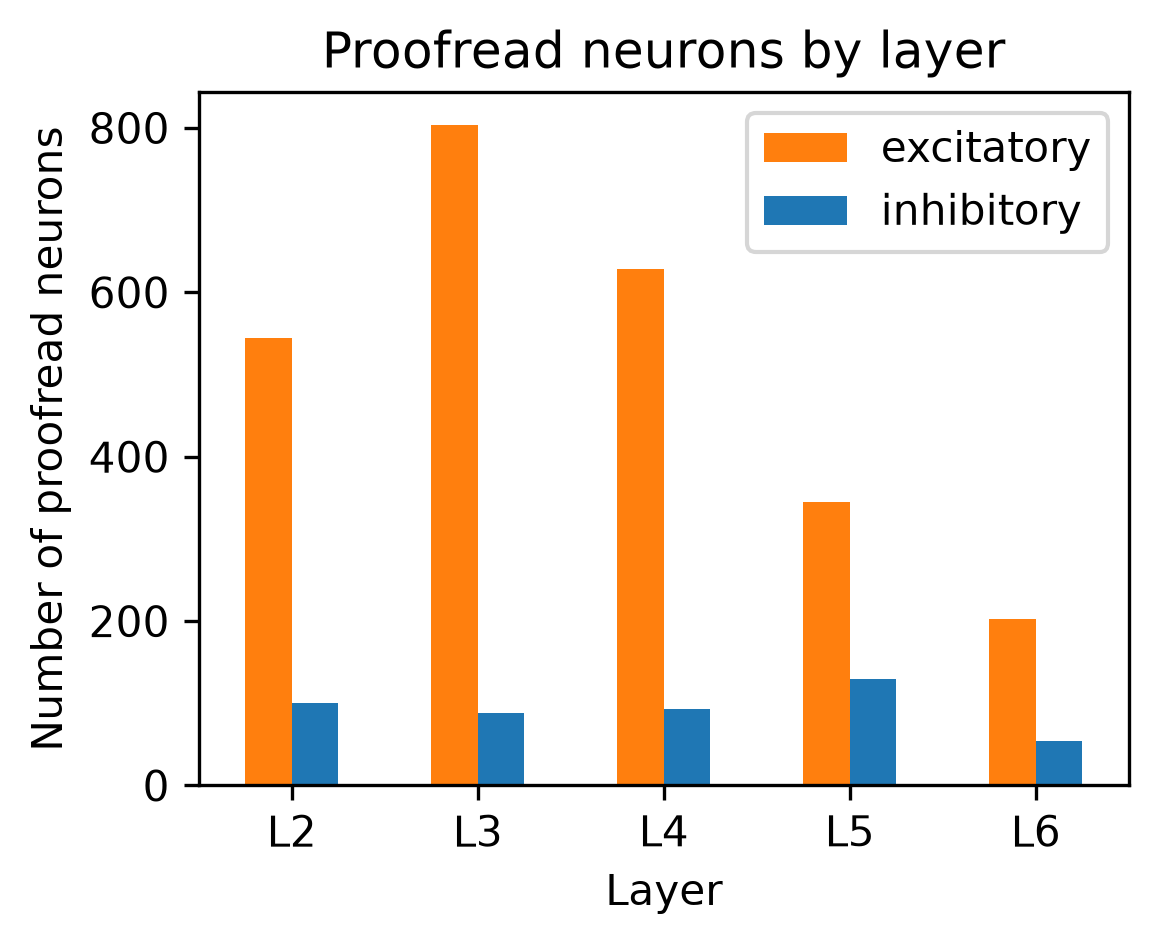

In [27]:
E_counts = E_meta.groupby("layer").size().reindex(LAYER_ORDER, fill_value=0)
I_counts = I_layers.groupby("layer").size().reindex(LAYER_ORDER, fill_value=0)
neuron_counts = pd.DataFrame({"excitatory": E_counts, "inhibitory": I_counts})
neuron_counts.to_csv(OUT / "proofread_neuron_counts_by_layer.csv")

fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)
neuron_counts.plot.bar(ax=ax, color=["tab:orange", "tab:blue"])
ax.set(xlabel="Layer", ylabel="Number of proofread neurons", title="Proofread neurons by layer")
ax.tick_params(axis="x", rotation=0)
# save(fig, "01_proofread_neuron_counts.png")


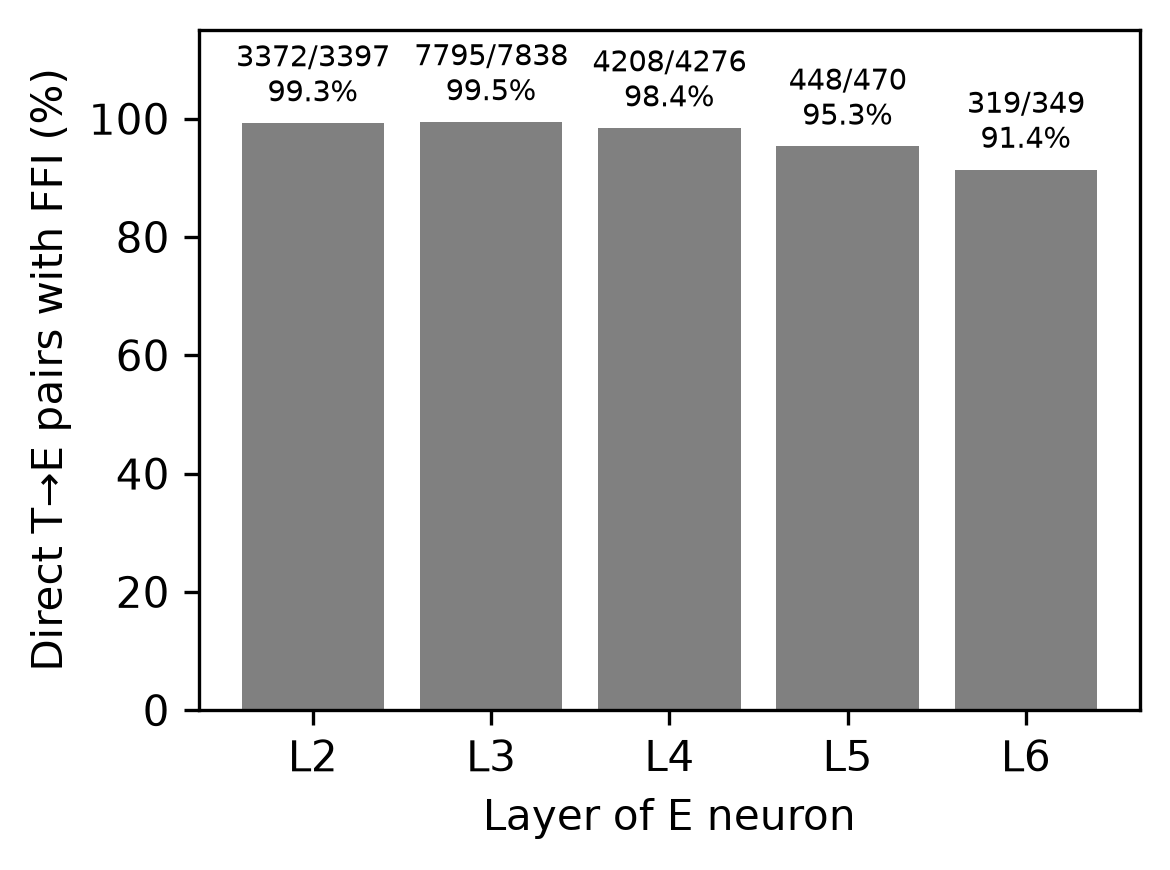

In [28]:
ffi_percent = (
    direct_pairs.dropna(subset=["layer"])
    .groupby("layer")["has_ffi"]
    .agg(
        n_direct="size",
        n_with_ffi="sum",
        percent_with_ffi="mean",
    )
    .reindex(LAYER_ORDER)
)

ffi_percent["percent_with_ffi"] *= 100

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

bars = ax.bar(
    ffi_percent.index,
    ffi_percent["percent_with_ffi"],
    color="gray",
)

for bar, (_, row) in zip(bars, ffi_percent.iterrows()):
    if pd.notna(row["percent_with_ffi"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{int(row["n_with_ffi"])}/{int(row["n_direct"])}\n'
            f'{row["percent_with_ffi"]:.1f}%',
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set(
    xlabel="Layer of E neuron",
    ylabel="Direct T→E pairs with FFI (%)",
    ylim=(0, 115),  # ラベル用のスペース
)

plt.tight_layout()
plt.show()

## Connection size

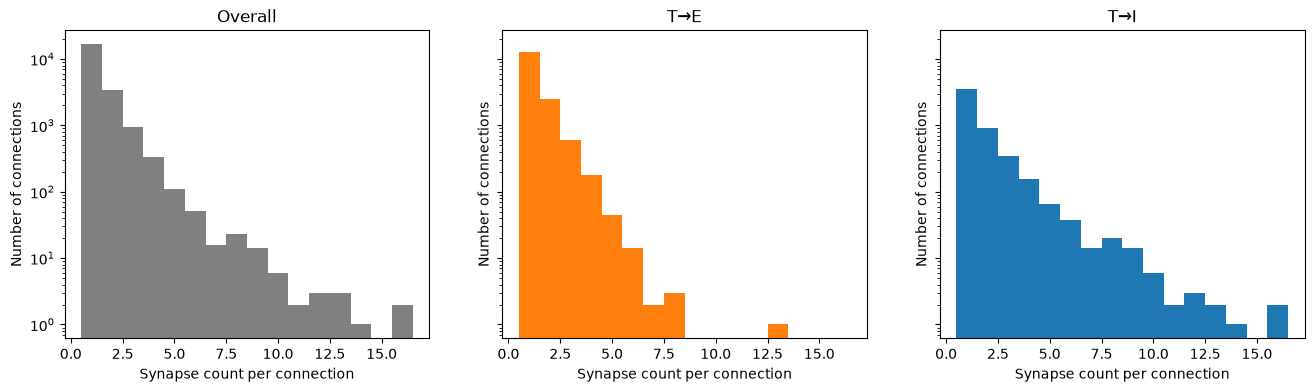

In [29]:
max_size = int(max(TE["direct_size"].max(), TI["TI_size"].max()))
bins = np.arange(0.5, max_size + 1.5, 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
axes[0].hist(pd.concat([TE["direct_size"], TI["TI_size"]]), bins=bins, color="gray")
axes[1].hist(TE["direct_size"], bins=bins, color="tab:orange")
axes[2].hist(TI["TI_size"], bins=bins, color="tab:blue")
for ax, title in zip(axes, ["Overall", "T→E", "T→I"]):
    ax.set(title=title, xlabel="Synapse count per connection", ylabel="Number of connections")
    ax.set_yscale("log")


Text(0.5, 0, 'Synapse count per connection')

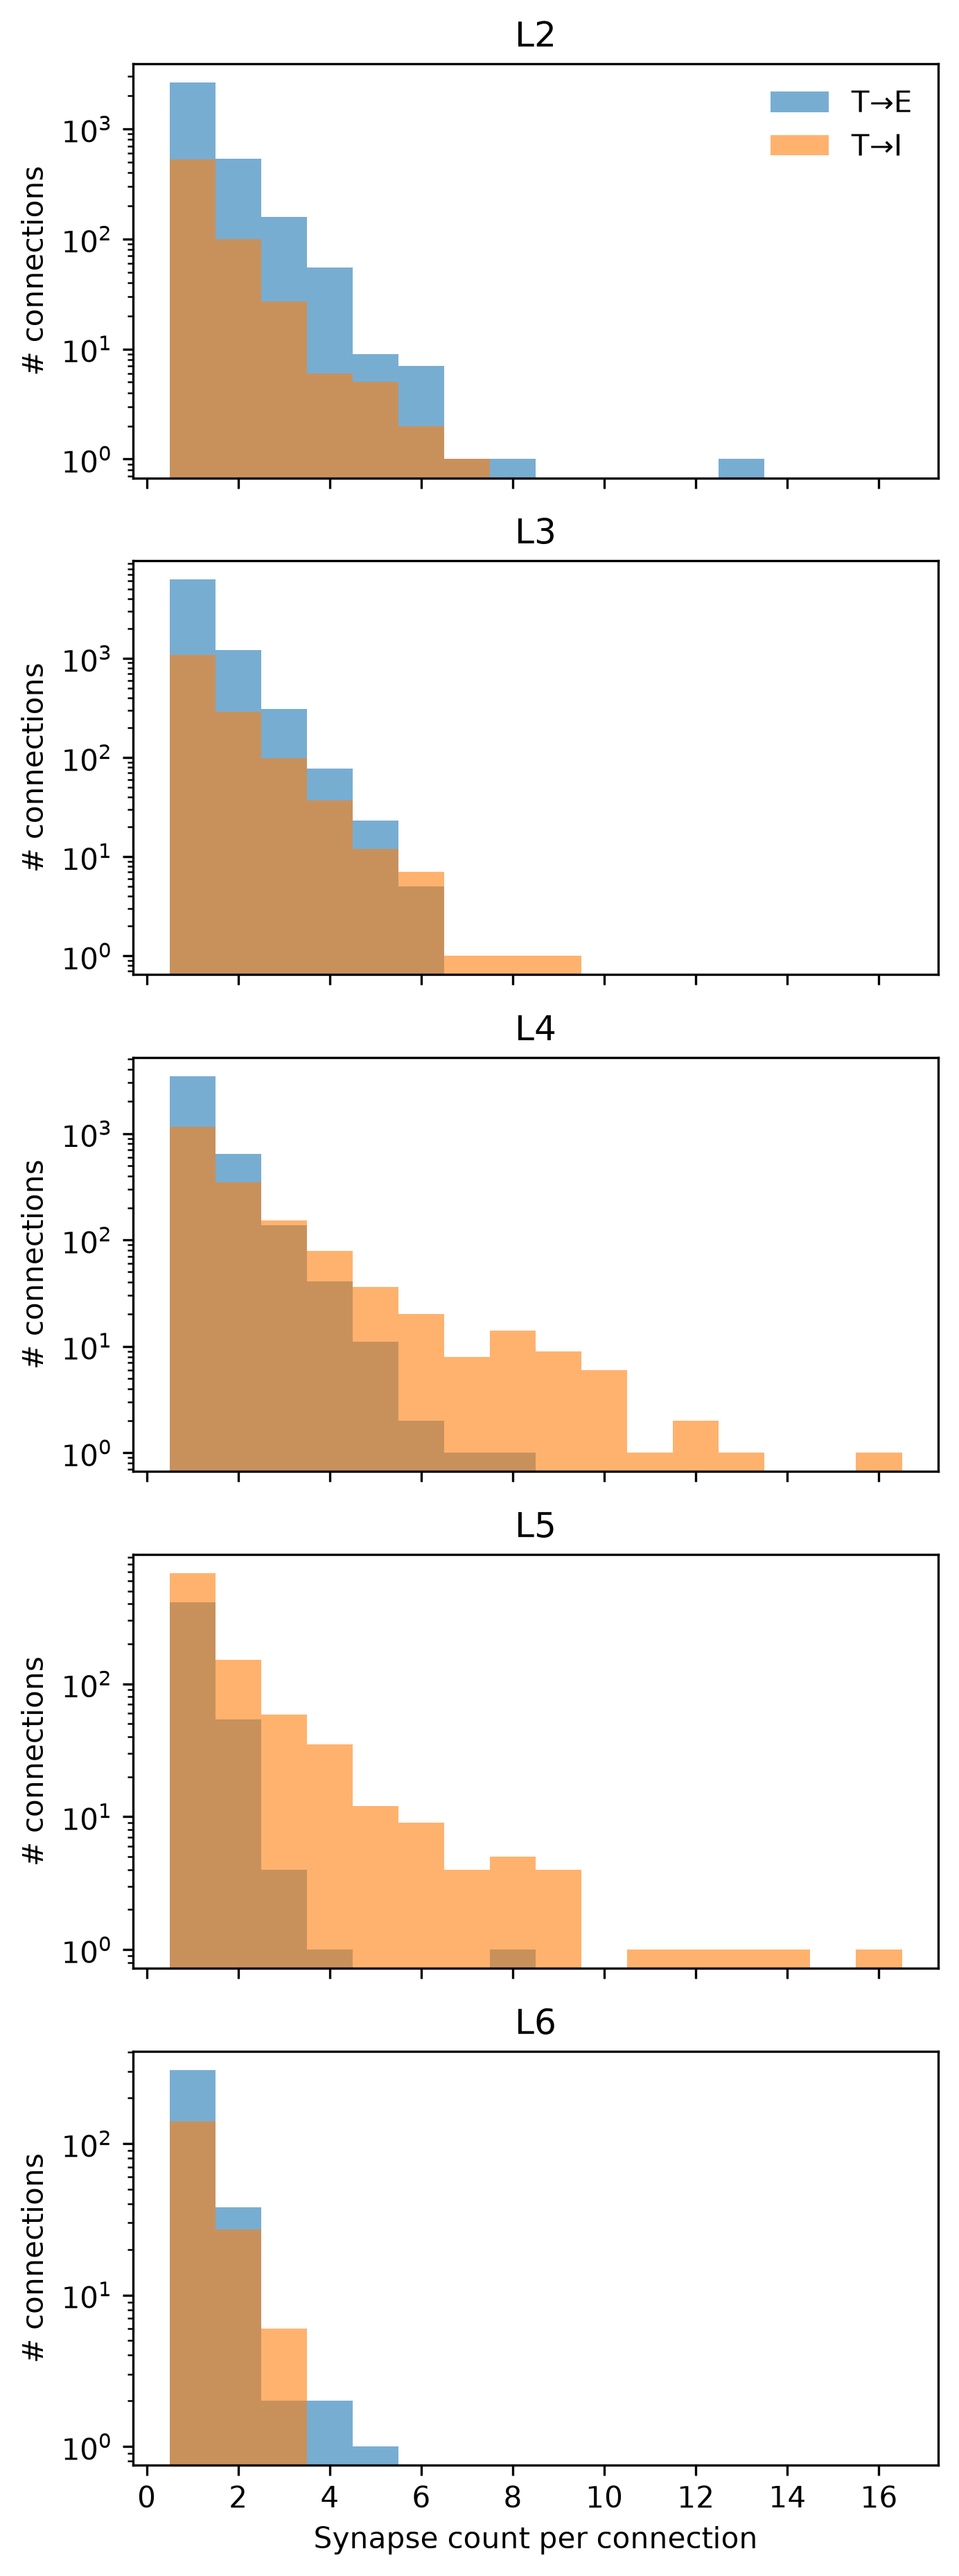

In [30]:
# T->E and T->I connection-size histograms by assigned layer 
TE_layer = TE.assign(layer=TE["post_pt_root_id"].map(e_to_layer), target="T→E", size=TE["direct_size"])
i_to_layer = I_layers.set_index("pt_root_id")["layer"]
TI_layer = TI.assign(layer=TI["post_pt_root_id"].map(i_to_layer), target="T→I", size=TI["TI_size"])
by_layer = pd.concat([TE_layer, TI_layer], ignore_index=True)
by_layer[["pre_pt_root_id", "post_pt_root_id", "layer", "target", "size"]].to_csv(
    OUT / "connection_sizes_by_layer.csv", index=False
)

fig, axes = plt.subplots(len(LAYER_ORDER), 1, figsize=(5, 15), sharex=True, dpi = 300)
for ax, layer in zip(axes, LAYER_ORDER):
    part = by_layer.loc[by_layer["layer"].eq(layer)]
    ax.hist(part.loc[part["target"].eq("T→E"), "size"], bins=bins, alpha=0.6, label="T→E")
    ax.hist(part.loc[part["target"].eq("T→I"), "size"], bins=bins, alpha=0.6, label="T→I")
    ax.set(title=layer, ylabel="# connections")
    ax.set_yscale("log")
axes[0].legend(frameon=False)
axes[-1].set_xlabel("Synapse count per connection")

Proofread I neurons (axon): 465
Direct T→E pairs: 16,330
Direct pairs accompanied by FFI: 98.8%


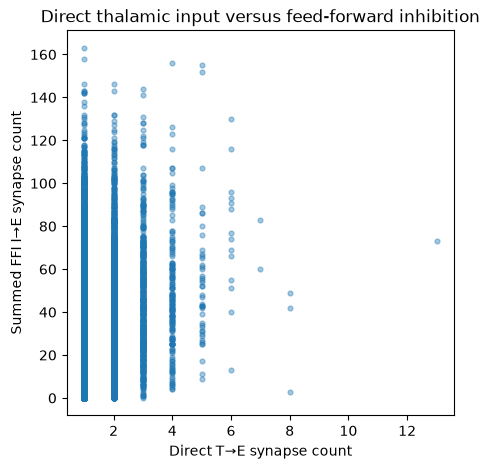

In [31]:
# ---------- 4. Direct T->E size versus summed feed-forward inhibition ----------
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(direct_pairs["direct_size"], direct_pairs["ffi_size"], s=12, alpha=0.4)
ax.set(
    xlabel="Direct T→E synapse count",
    ylabel="Summed FFI I→E synapse count",
    title="Direct thalamic input versus feed-forward inhibition",
)


print(f"Proofread I neurons (axon): {len(proofread_I_ids):,}")
print(f"Direct T→E pairs: {len(direct_pairs):,}")
print(f"Direct pairs accompanied by FFI: {direct_pairs['has_ffi'].mean():.1%}")

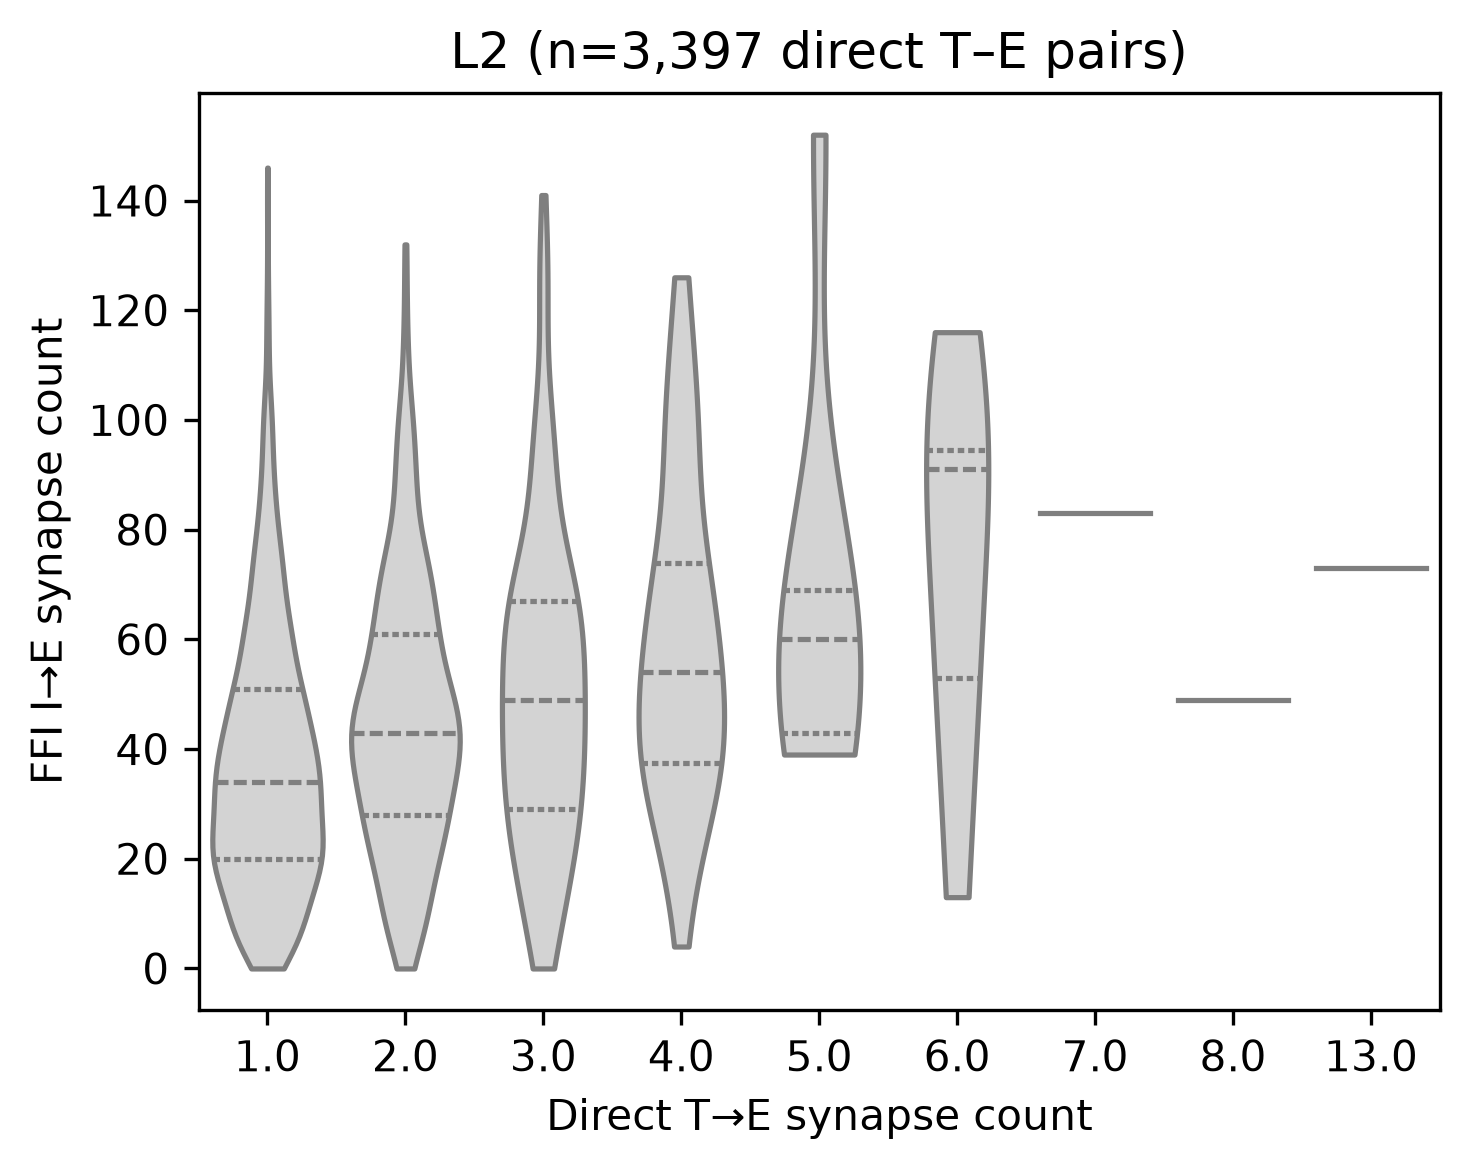

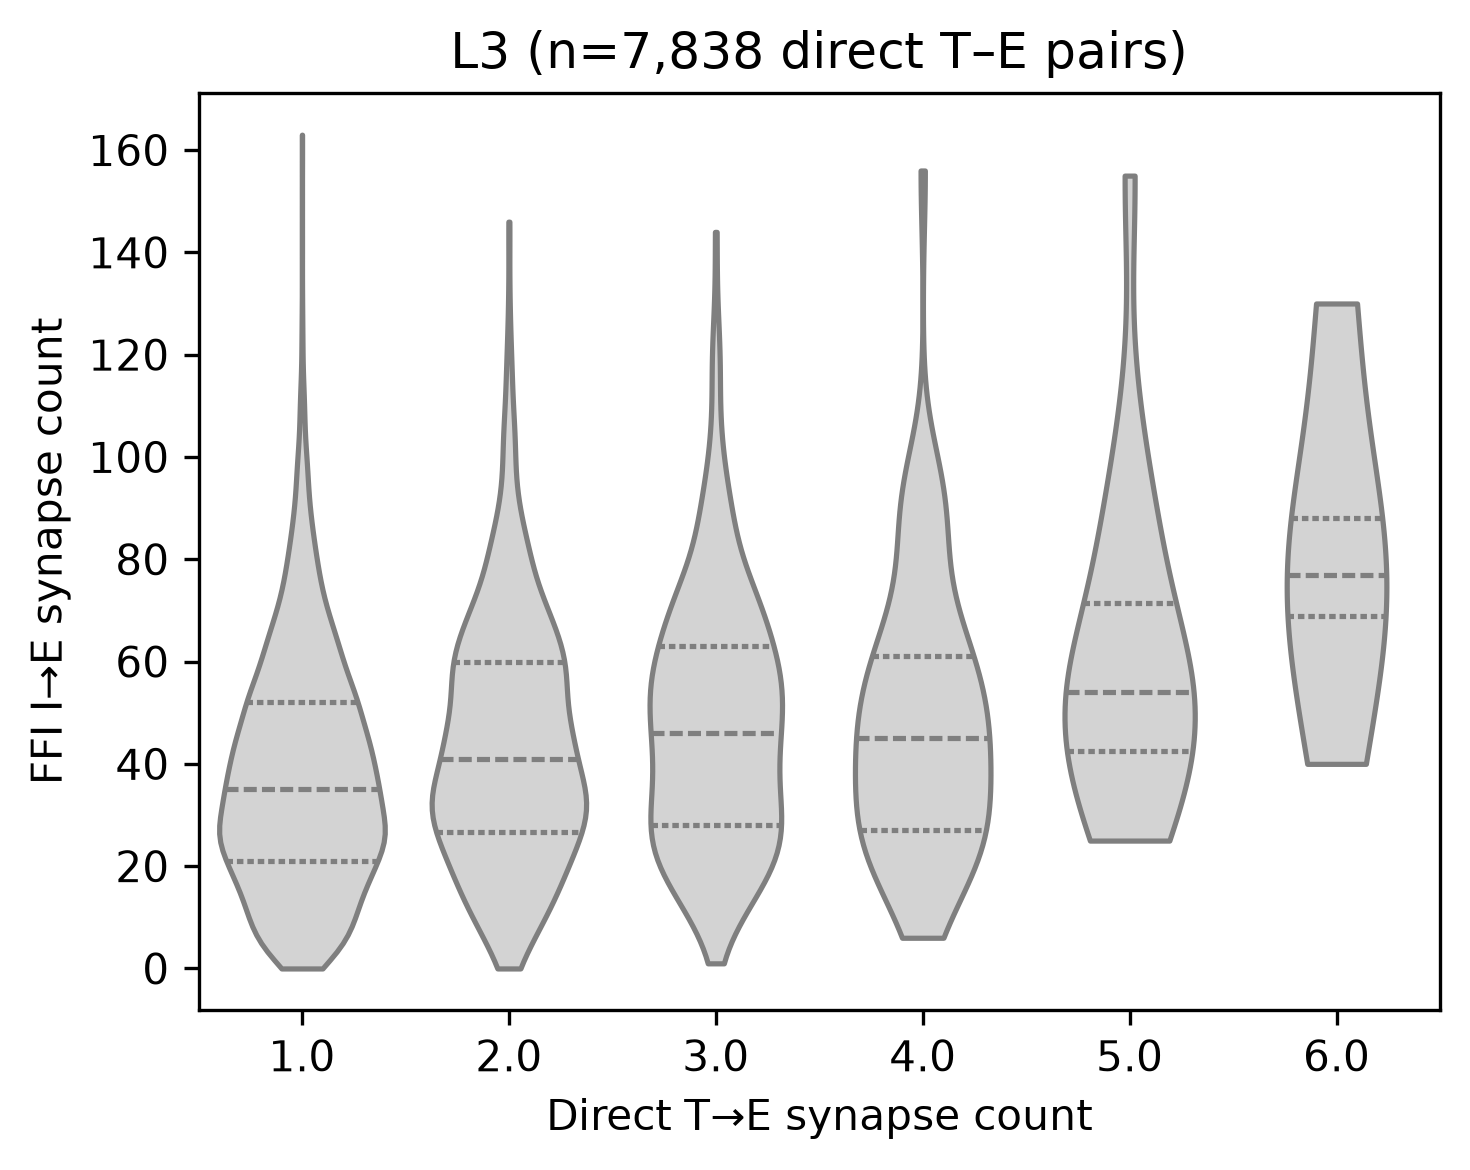

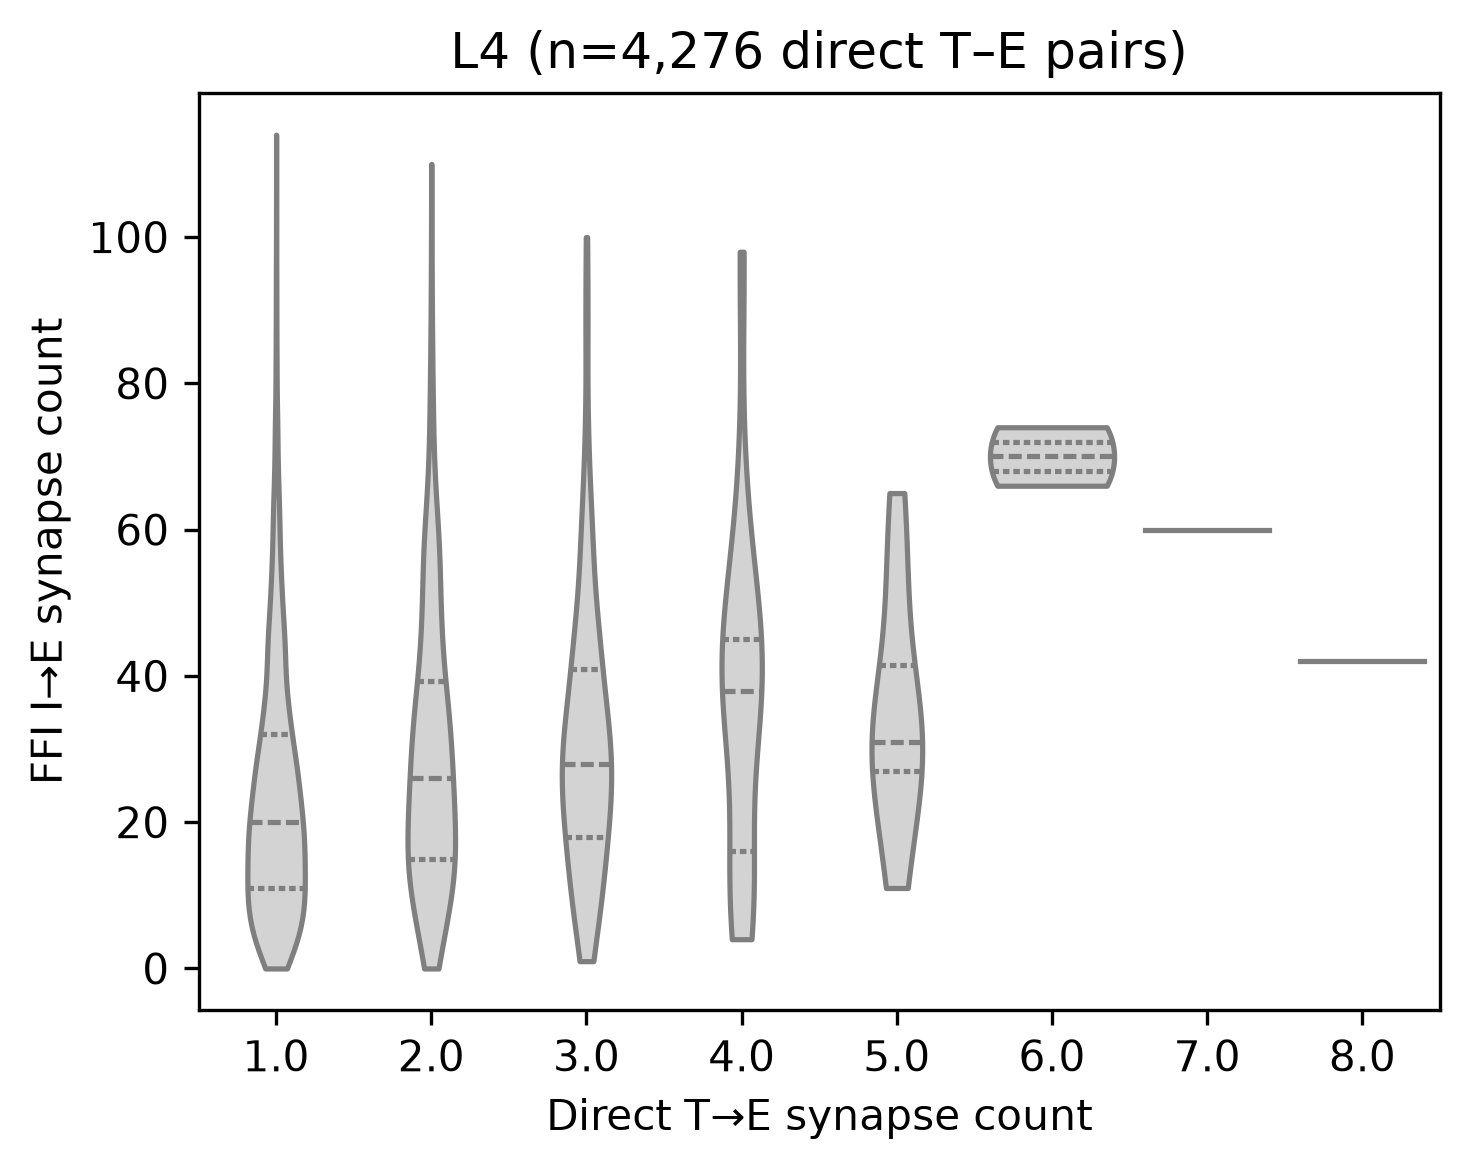

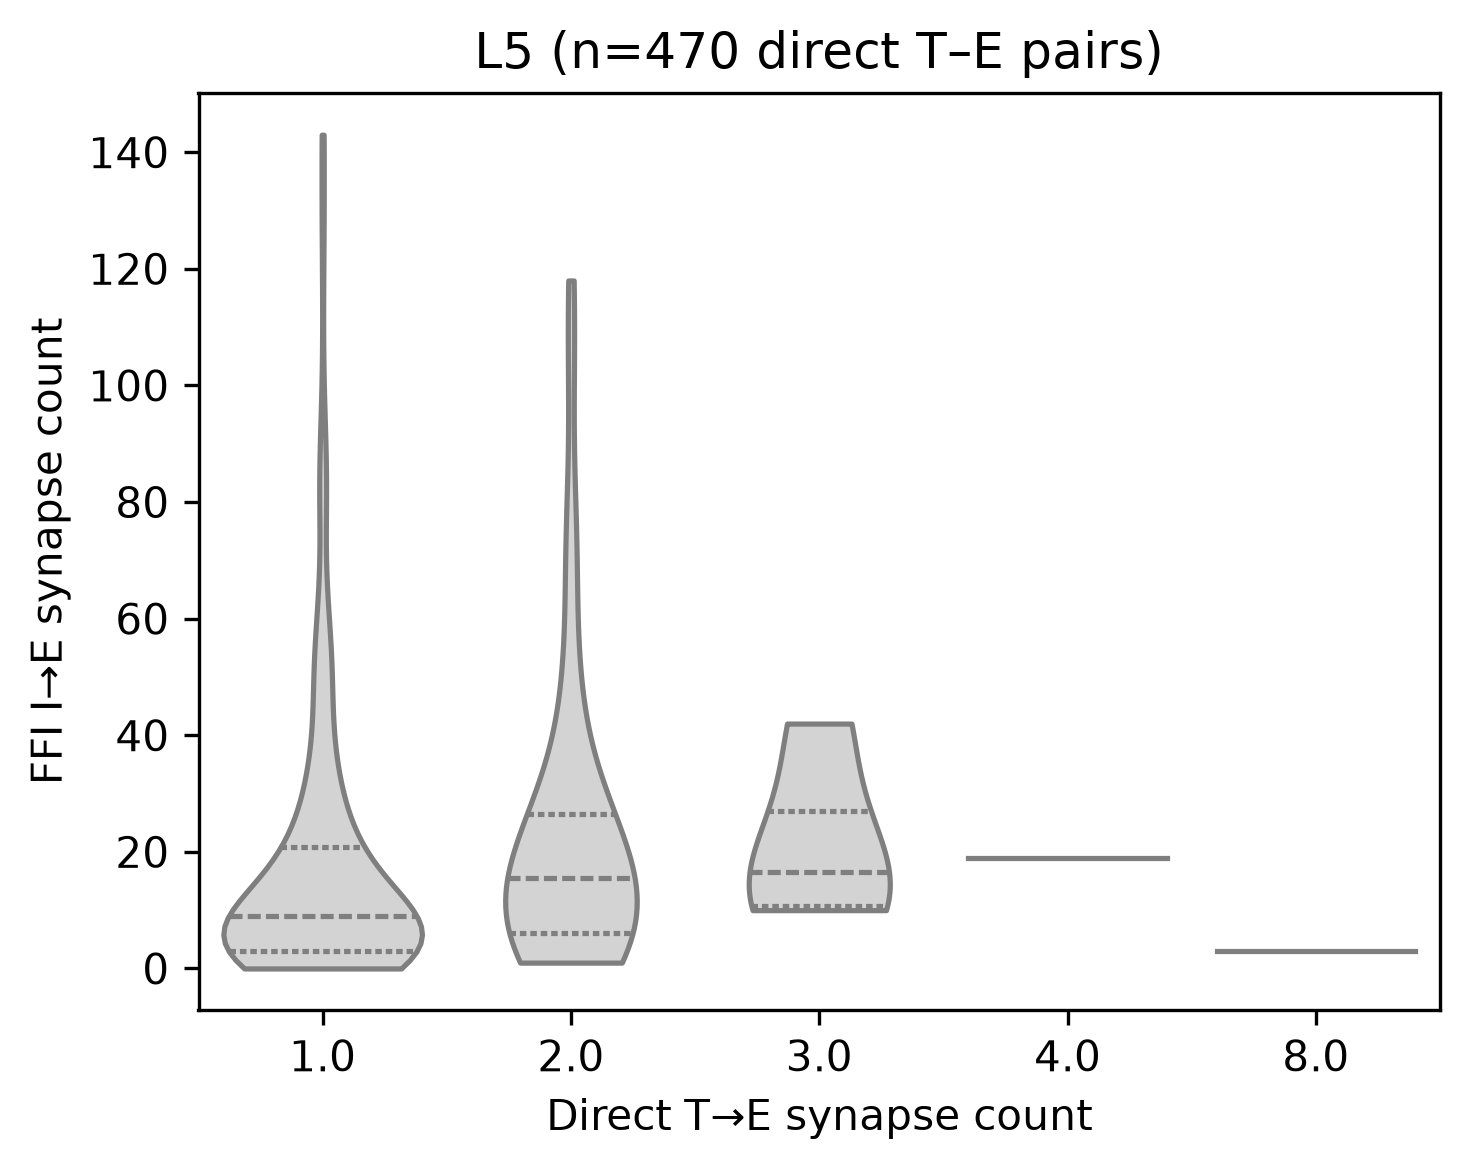

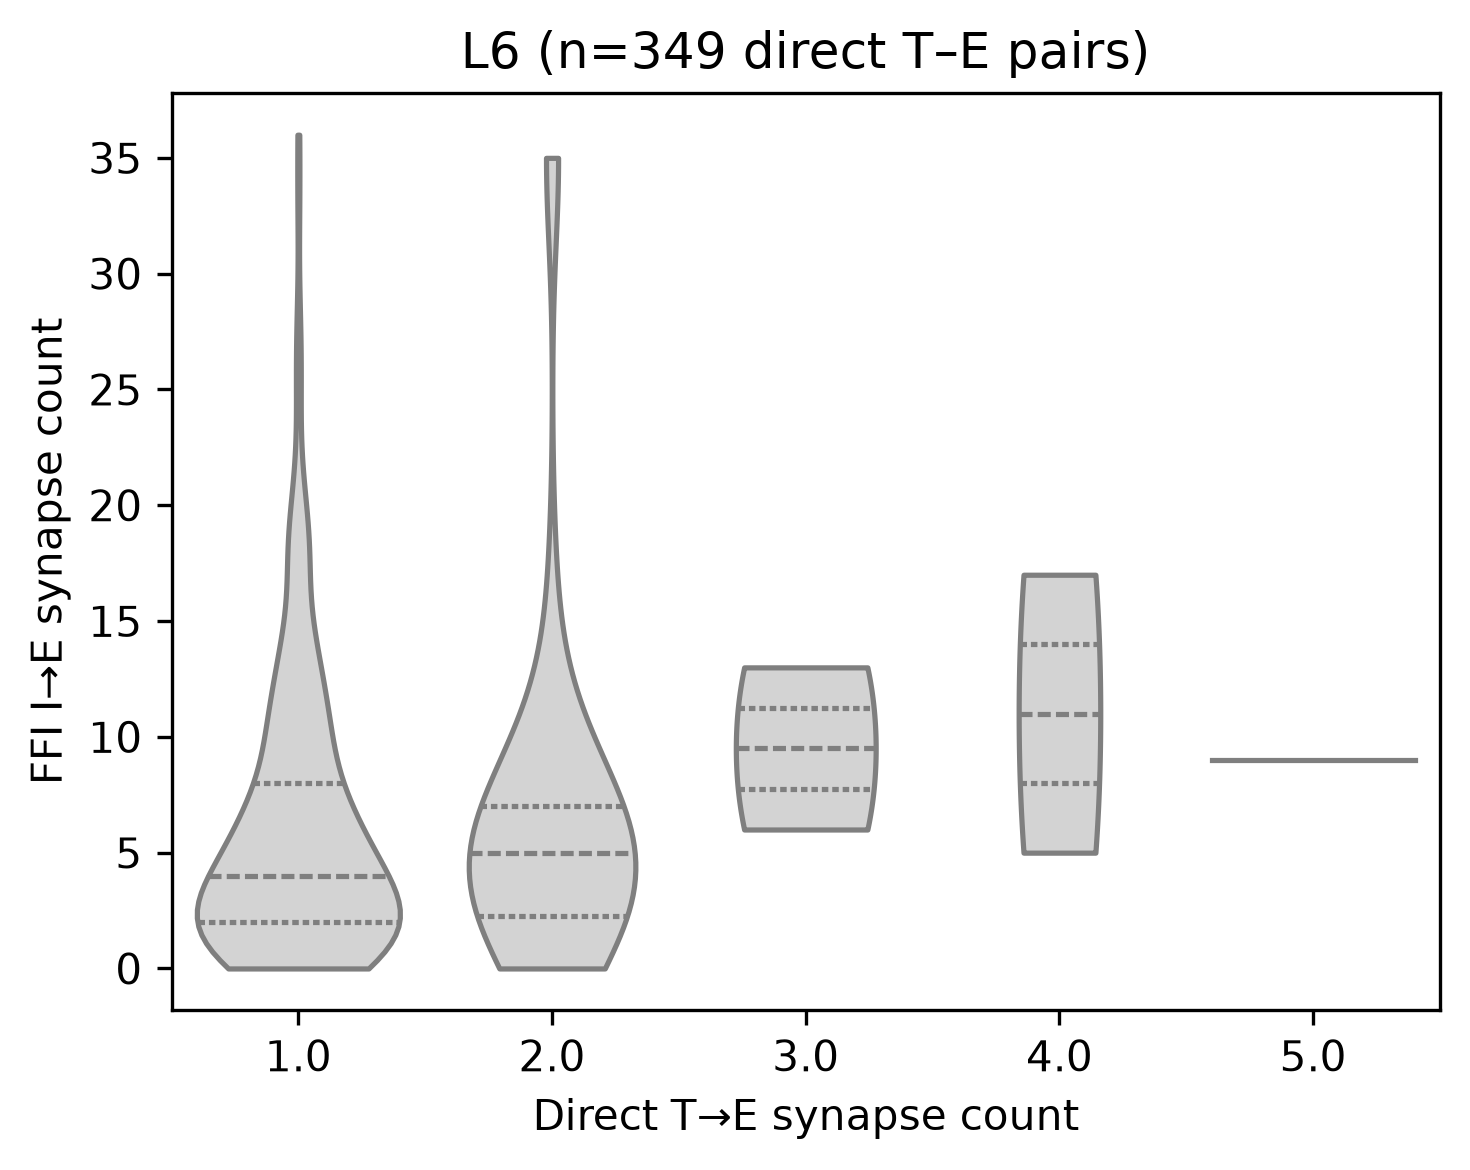

In [32]:
import seaborn as sns

for layer in LAYER_ORDER:
    layer_df = direct_pairs.loc[
        direct_pairs["layer"].eq(layer)
    ].copy()

    if layer_df.empty:
        continue

    direct_order = sorted(
        layer_df["direct_size"].unique()
    )

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

    sns.violinplot(
        data=layer_df,
        x="direct_size",
        y="ffi_size",
        order=direct_order,
        inner="quartile",
        cut=0,
        color="lightgray",
        ax=ax,
    )

    ax.set(
        xlabel="Direct T→E synapse count",
        ylabel="FFI I→E synapse count",
        title=f"{layer} (n={len(layer_df):,} direct T–E pairs)",
    )

    plt.tight_layout()
    plt.show()

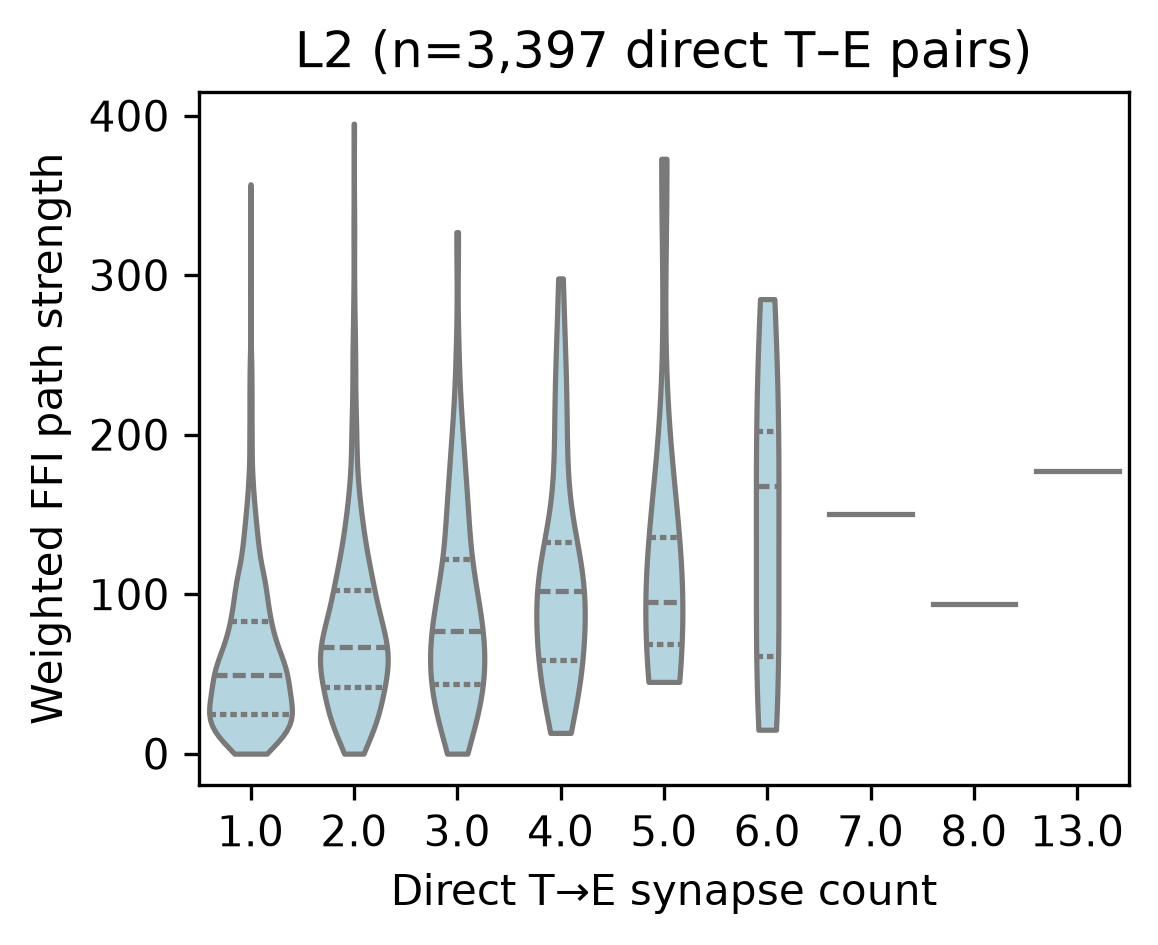

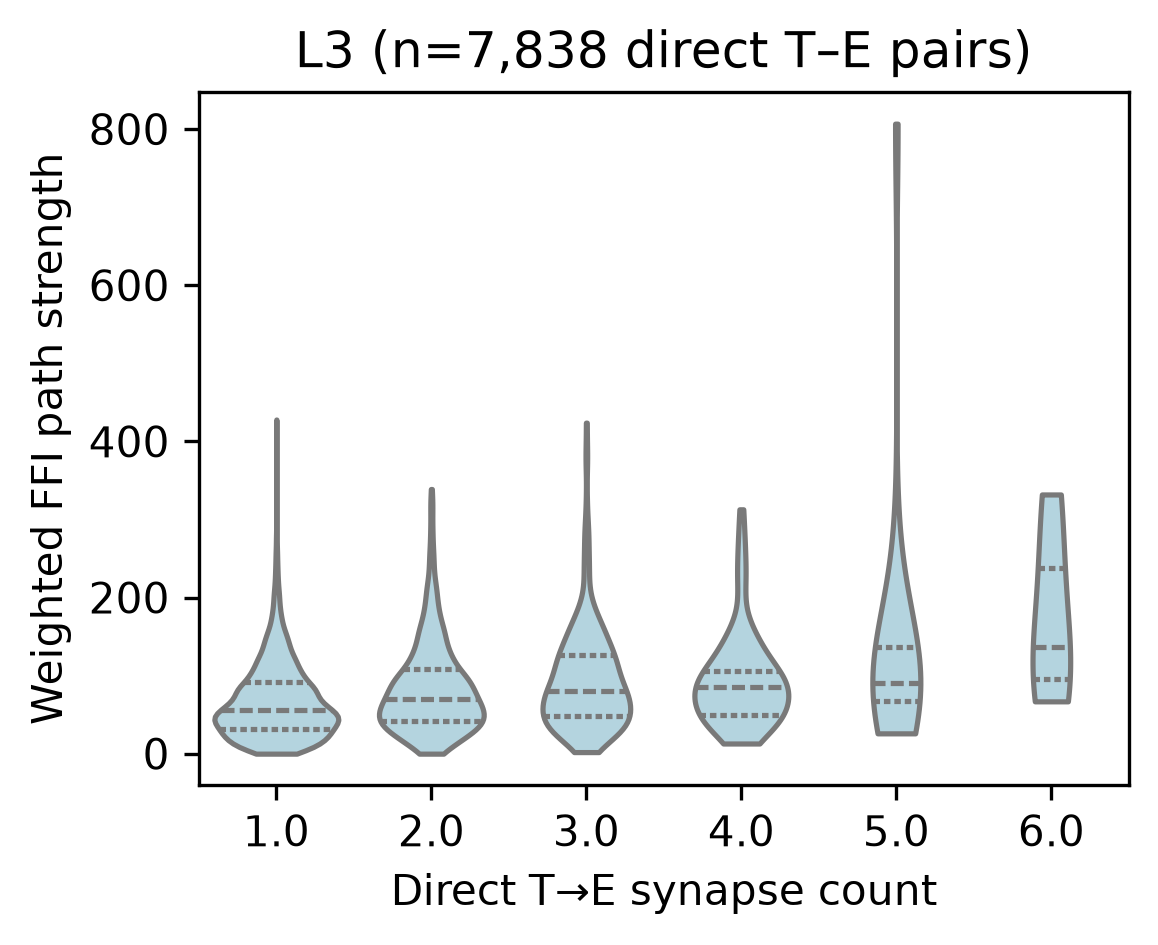

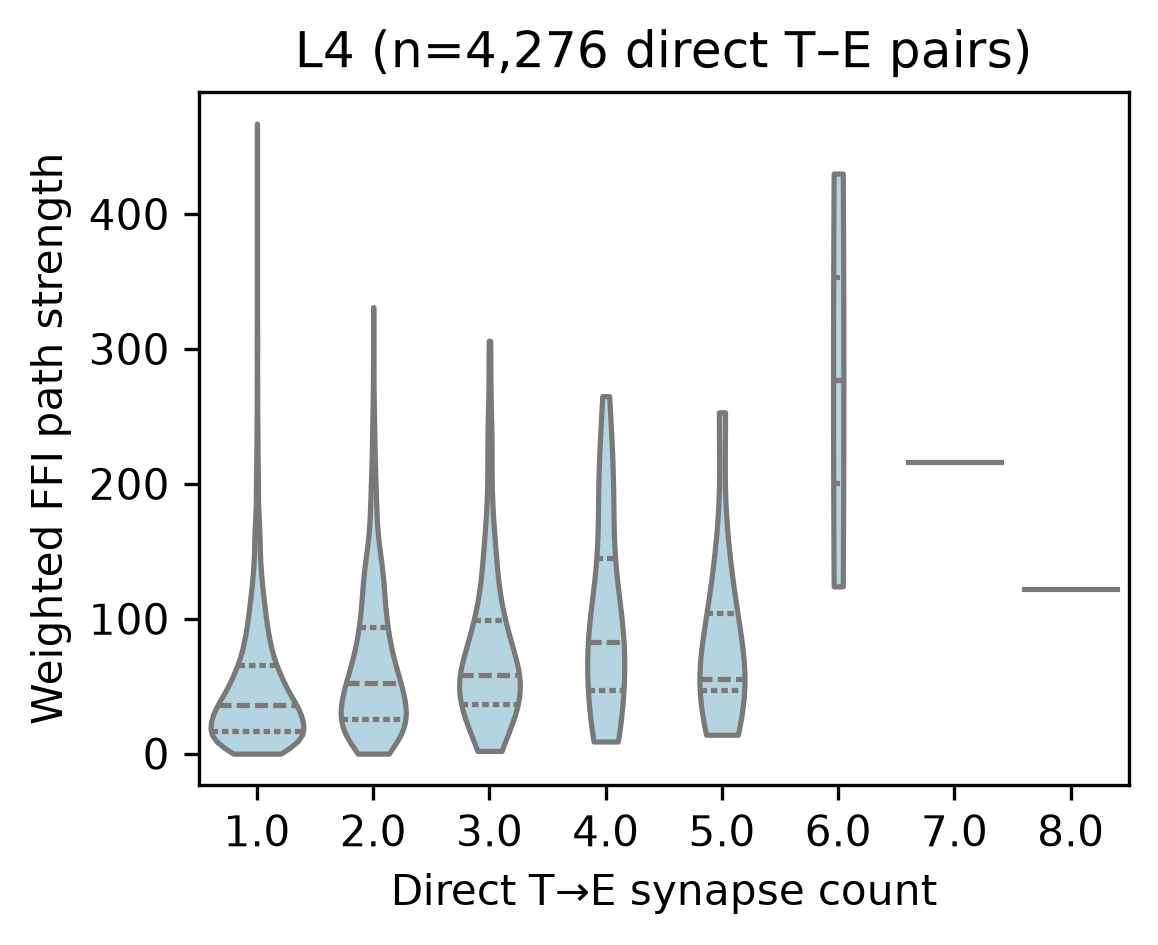

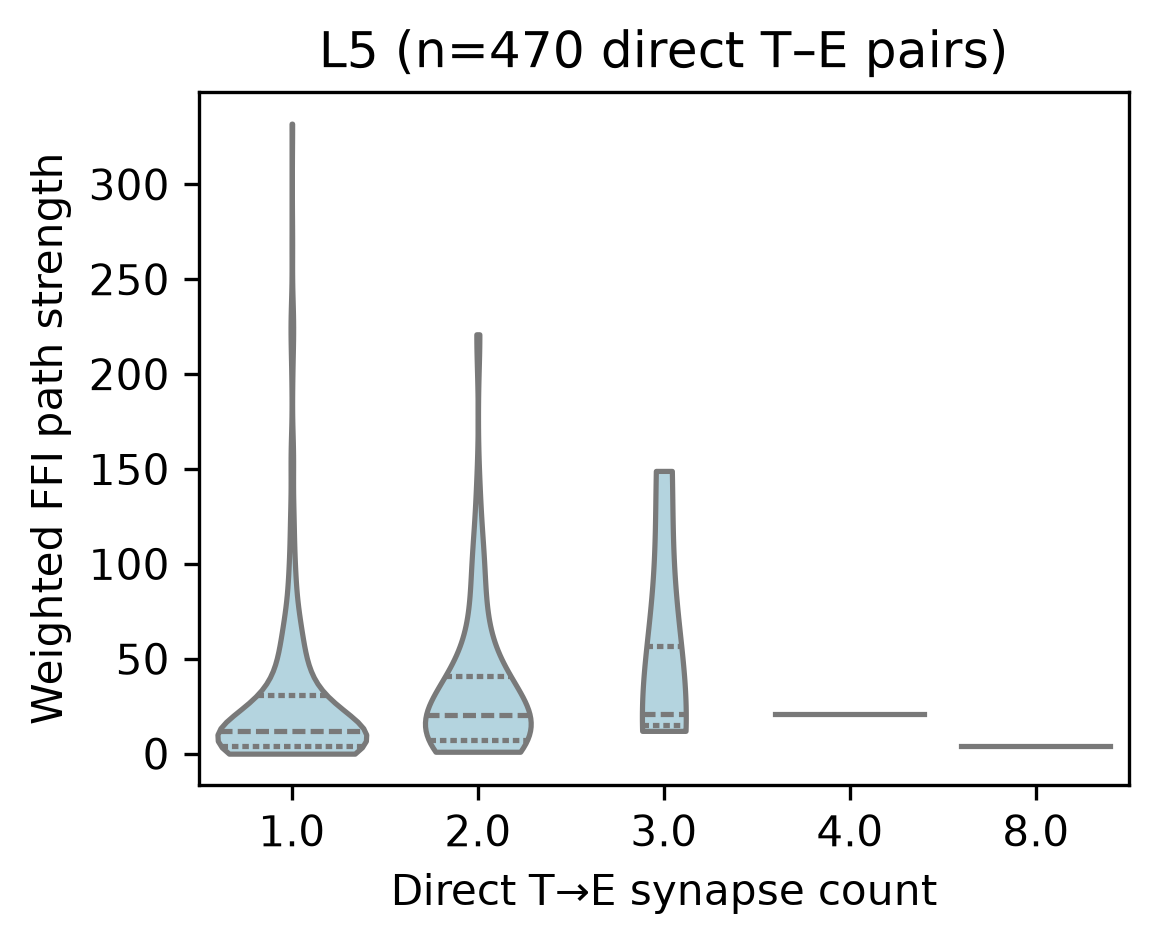

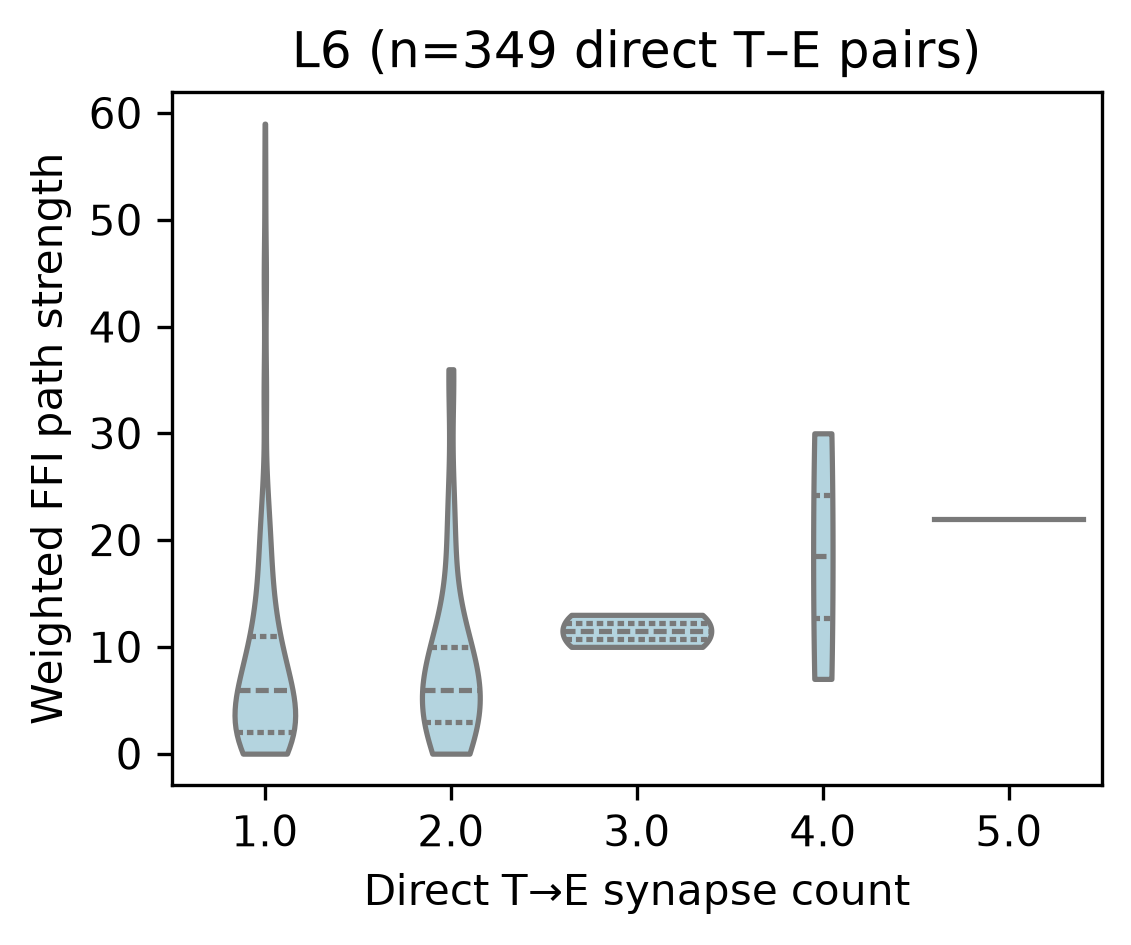

In [33]:
# weighted path strength ver
weighted_ymax = direct_pairs["weighted_path_strength"].max()
for layer in LAYER_ORDER:
    part = direct_pairs.loc[direct_pairs["layer"].eq(layer)].copy()
    if part.empty:
        continue

    direct_order = sorted(part["direct_size"].unique())
    fig, ax = plt.subplots(figsize=(4,3), dpi = 300)
    sns.violinplot(
        data=part,
        x="direct_size",
        y="weighted_path_strength",
        order=direct_order,
        inner="quartile",
        cut=0,
        color="lightblue",
        ax=ax,
    )
    ax.set(
        xlabel="Direct T→E synapse count",
        ylabel="Weighted FFI path strength",
        title=f"{layer} (n={len(part):,} direct T–E pairs)",
        # ylim=(0, weighted_ymax * 1.05 if weighted_ymax > 0 else 1),
    )

Text(0, 0.5, 'FFI I→E size sum')

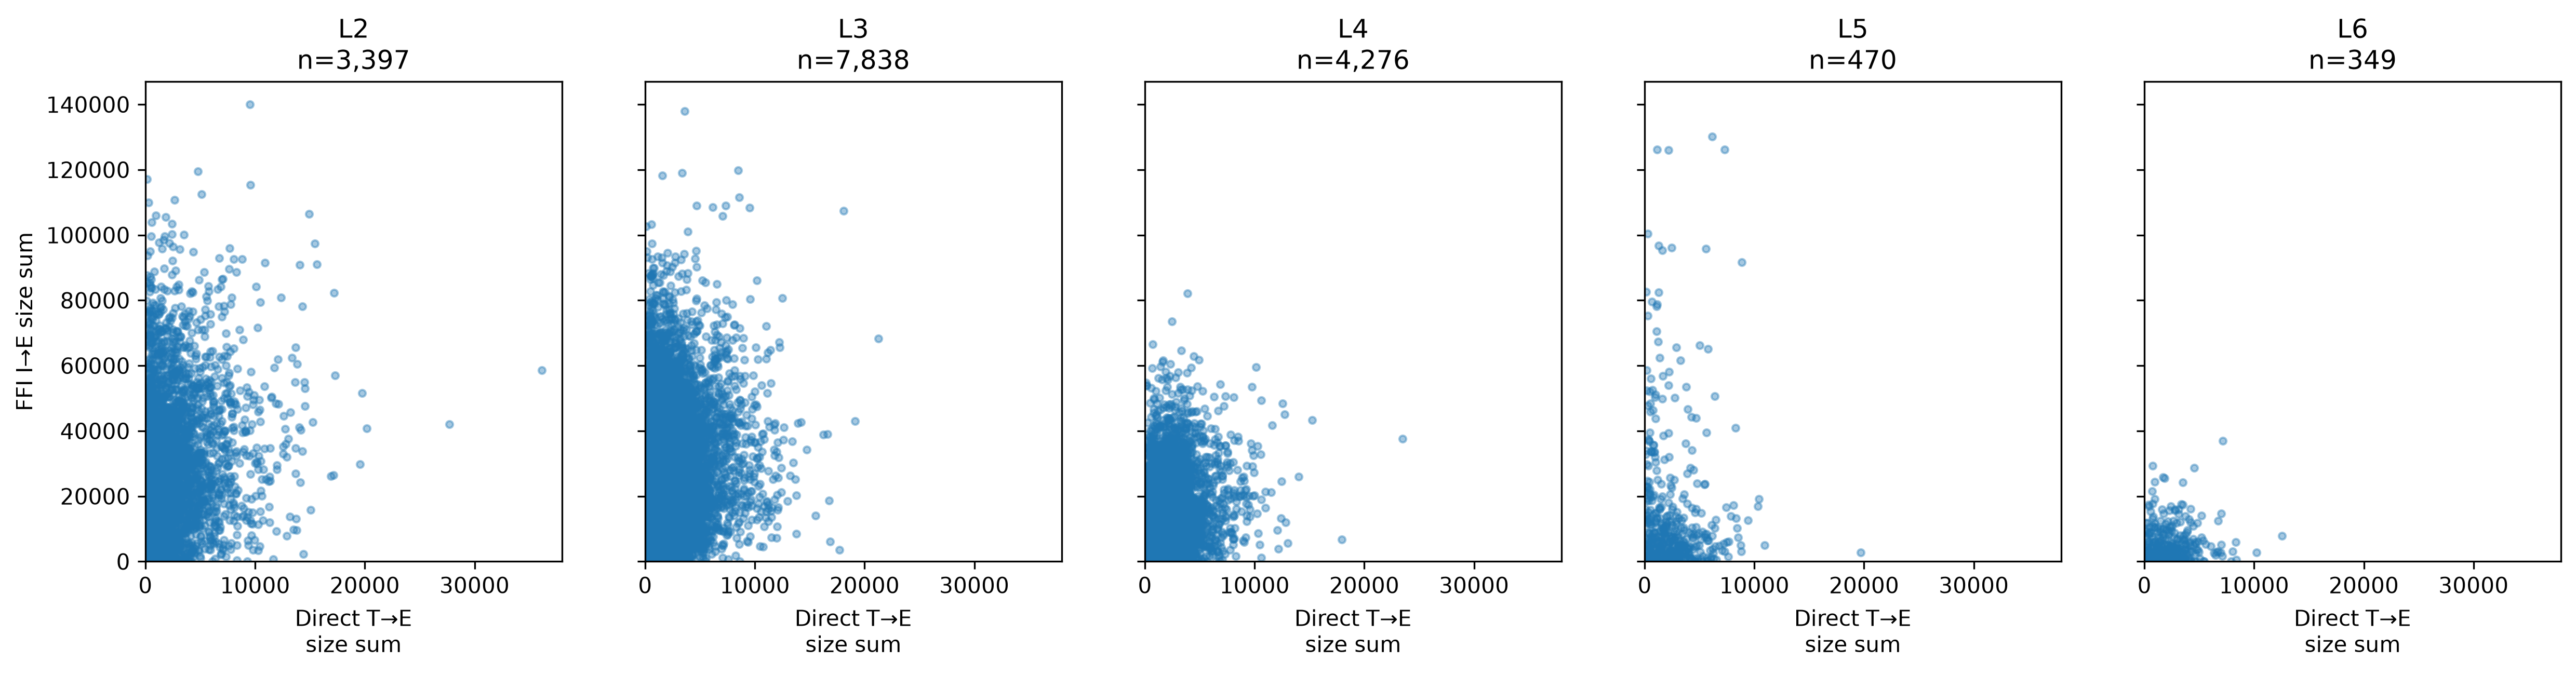

In [34]:
# Here x is the size of one synapse, and y is the number of synapses.
physical_values = pd.concat([TE_syn["size"], TI_syn["size"]]).dropna()
physical_bins = np.histogram_bin_edges(physical_values, bins=40)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
axes[0].hist(physical_values, bins=physical_bins, color="gray")
axes[1].hist(TE_syn["size"].dropna(), bins=physical_bins, color="tab:orange")
axes[2].hist(TI_syn["size"].dropna(), bins=physical_bins, color="tab:blue")
for ax, title in zip(axes, ["Overall", "T→E", "T→I"]):
    ax.set(title=title, xlabel="Synapse size", ylabel="Number of synapses")
    ax.set_yscale("log")
save(fig, "06_physical_synapse_size_histograms.png")

# Attach the postsynaptic neuron's layer to each individual synapse.
TE_syn_size_layer = TE_syn.assign(
    layer=TE_syn["post_pt_root_id"].map(e_to_layer), target="T→E"
)
TI_syn_size_layer = TI_syn.assign(
    layer=TI_syn["post_pt_root_id"].map(i_to_layer), target="T→I"
)
physical_by_layer = pd.concat(
    [TE_syn_size_layer, TI_syn_size_layer], ignore_index=True
)
physical_by_layer[["pre_pt_root_id", "post_pt_root_id", "layer", "target", "size"]].to_csv(
    OUT / "physical_synapse_sizes_by_layer.csv", index=False
)

fig, axes = plt.subplots(len(LAYER_ORDER), 1, figsize=(6, 12), sharex=True)
for ax, layer in zip(axes, LAYER_ORDER):
    part = physical_by_layer.loc[physical_by_layer["layer"].eq(layer)]
    ax.hist(
        part.loc[part["target"].eq("T→E"), "size"].dropna(),
        bins=physical_bins, alpha=0.6, label="T→E",
    )
    ax.hist(
        part.loc[part["target"].eq("T→I"), "size"].dropna(),
        bins=physical_bins, alpha=0.6, label="T→I",
    )
    ax.set(title=layer, ylabel="# synapses")
    ax.set_yscale("log")
axes[0].legend(frameon=False)
axes[-1].set_xlabel("Synapse size")
save(fig, "07_physical_synapse_size_histograms_by_layer.png")

# Connection-level summed physical size for the main strength question.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    direct_pairs["direct_physical_size"],
    direct_pairs["ffi_physical_size"],
    s=12, alpha=0.4,
)
ax.set(
    xlabel="Summed direct T→E synapse size",
    ylabel="Summed FFI I→E synapse size",
    title="Direct input versus FFI: physical synapse size",
)
save(fig, "08_direct_physical_size_vs_FFI_physical_size.png")

# The same size-strength relationship, shown separately for each E layer.
# Common limits make the layers directly comparable.
x_max = direct_pairs["direct_physical_size"].max()
y_max = direct_pairs["ffi_physical_size"].max()

fig, axes = plt.subplots(1, len(LAYER_ORDER), figsize=(20, 4), sharex=True, sharey=True, dpi = 300)
for ax, layer in zip(axes, LAYER_ORDER):
    part = direct_pairs.loc[direct_pairs["layer"].eq(layer)]
    ax.scatter(
        part["direct_physical_size"],
        part["ffi_physical_size"],
        s=10, alpha=0.4,
    )
    ax.set_title(f"{layer}\nn={len(part):,}")
    ax.set_xlabel("Direct T→E\nsize sum")
    ax.set_xlim(0, x_max * 1.05 if x_max > 0 else 1)
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1)
axes[0].set_ylabel("FFI I→E size sum")

[Text(0.5, 0, 'Summed direct T→E synapse size'),
 Text(0, 0.5, 'Size-weighted T→I→E path strength'),
 Text(0.5, 1.0, 'Direct input versus size-weighted FFI path strength')]

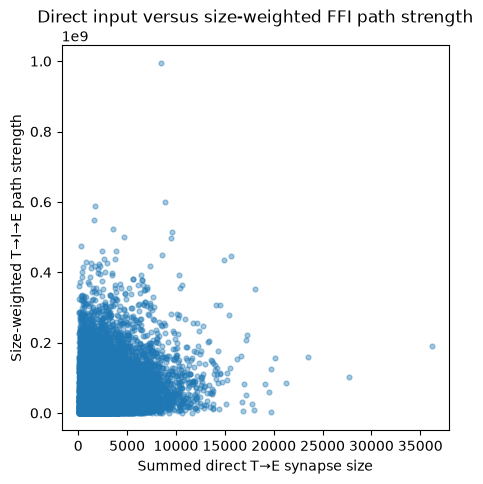

In [38]:
# Include T->I synapse size as well as I->E synapse size in the FFI index.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    direct_pairs["direct_physical_size"],
    direct_pairs["weighted_physical_path_strength"],
    s=12, alpha=0.4,
)
ax.set(
    xlabel="Summed direct T→E synapse size",
    ylabel="Size-weighted T→I→E path strength",
    title="Direct input versus size-weighted FFI path strength",
)

Text(0, 0.5, 'Size-weighted T→I→E path strength')

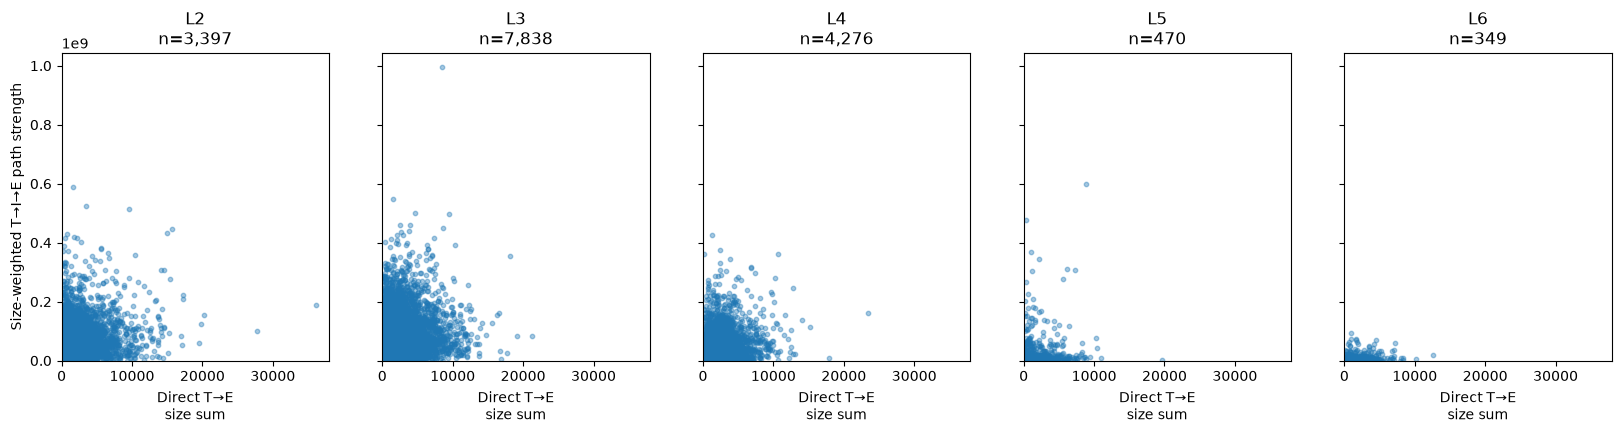

In [39]:
weighted_physical_ymax = direct_pairs["weighted_physical_path_strength"].max()
fig, axes = plt.subplots(1, len(LAYER_ORDER), figsize=(20, 4), sharex=True, sharey=True)
for ax, layer in zip(axes, LAYER_ORDER):
    part = direct_pairs.loc[direct_pairs["layer"].eq(layer)]
    ax.scatter(
        part["direct_physical_size"],
        part["weighted_physical_path_strength"],
        s=10, alpha=0.4,
    )
    ax.set_title(f"{layer}\nn={len(part):,}")
    ax.set_xlabel("Direct T→E\nsize sum")
    ax.set_xlim(0, x_max * 1.05 if x_max > 0 else 1)
    ax.set_ylim(
        0,
        weighted_physical_ymax * 1.05 if weighted_physical_ymax > 0 else 1,
    )
axes[0].set_ylabel("Size-weighted T→I→E path strength")